In [2]:
# TOPIC 1 — Train Test Split 

from sklearn.model_selection import train_test_split
import numpy as np

# ============================================
# WHAT IS TRAIN TEST SPLIT?
# ============================================

# Imagin you are preparing for an exam
# You have 100 practice questions
#
# What does a smart student do?
# Practice with 80 questions (TRAIN)
# Keep 20 questions for final review (TEST)
# In last you have 20 questions for final review
# 
#
# That's what we do in Machine Learning!

# Sample data
X = np.array([[1], [2], [3], [4], [5],
              [6], [7], [8], [9], [10]])  # Features
y = np.array([10, 20, 30, 40, 50,
              60, 70, 80, 90, 100])       # Target

# Split It
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test, 80% train
    random_state=42     # reproducible results
)

print("Total data:", len(X))           # 10
print("Training data:", len(X_train)) # 8  (80%)
print("Testing data:", len(X_test))   # 2  (20%)

print("\nX_train:", X_train.flatten())
print("y_train:", y_train)
print("\nX_test:", X_test.flatten())
print("y_test:", y_test)

Total data: 10
Training data: 8
Testing data: 2

X_train: [ 6  1  8  3 10  5  4  7]
y_train: [ 60  10  80  30 100  50  40  70]

X_test: [9 2]
y_test: [90 20]


Data Sample:
   Study_Hours      Marks
0     4.370861  39.772985
1     9.556429  84.512822
2     7.587945  68.750313
3     6.387926  47.553493
4     2.404168  20.539150

Shape: (100, 2)

X shape: (100, 1)
y shape: (100,)

Training samples: 80
Testing samples: 20

Model Trained! ✅
Slope (m):     8.78
Intercept (c): 0.94
Formula: Marks = 8.78 × Hours + 0.94

Predictions vs Actual:
   Study_Hours  Actual_Marks  Predicted_Marks
0     1.572025     17.430994             14.7
1     9.053446     78.963637             80.4
2     7.950203     65.367073             70.7
3     6.962701     58.117368             62.0
4     3.329020     33.916338             30.2
5     4.961372     46.160089             44.5
6     3.629302     32.689284             32.8
7     8.767931     88.240250             77.9
8     1.185260     15.244355             11.3
9     4.370861     39.772985             39.3

--- Model Performance ---
RMSE : 4.04
R²   : 0.9732


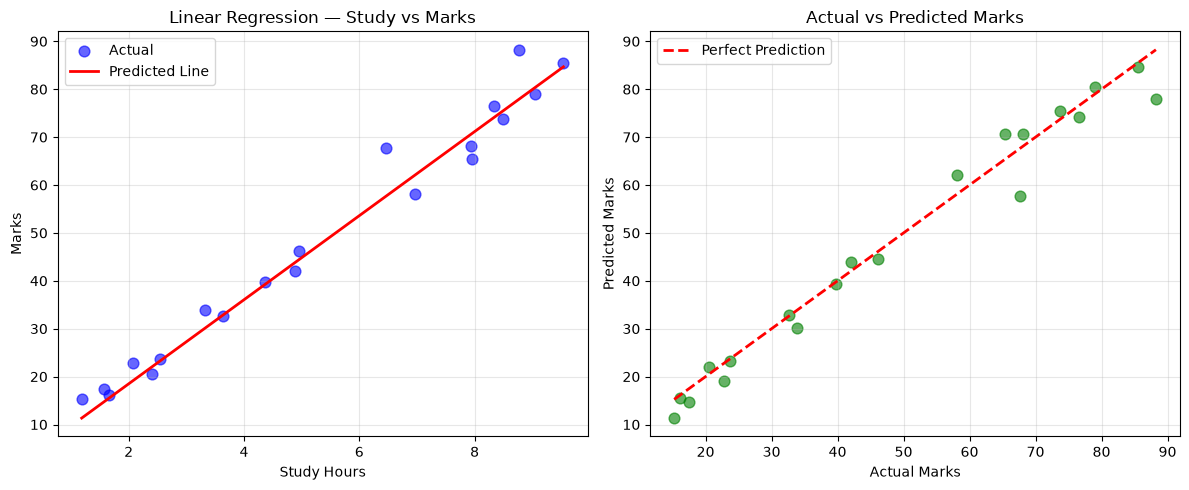


--- New Predictions ---
  3 hours study → 27.3 marks predicted
  5 hours study → 44.8 marks predicted
  7 hours study → 62.4 marks predicted
  9 hours study → 79.9 marks predicted


c:\Users\Areesha Khan\OneDrive\Desktop\python series\libraries\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [3]:
#  TOPIC 2 — Linear Regression (First Algorithm!)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ============================================
# WHAT IS LINEAR REGRESSION?
# ============================================
# Draw a straight line through data points
# From that line, predict new values
#
# Example:
# More study → More marks
# A straight line relationship!
#
# Formula: y = mx + c
# m = slope (x axis pe kitna upar neeche ja raha he)
# c = intercept (y axis pe kahan start)

np.random.seed(42)

# Making data — Study hours vs Marks
study_hours = np.random.uniform(1, 10, 100)
marks = study_hours * 9 + np.random.normal(0, 5, 100)
marks = np.clip(marks, 0, 100)

# DataFrame banao
df = pd.DataFrame({
    'Study_Hours': study_hours,
    'Marks': marks
})

print("Data Sample:")
print(df.head())
print("\nShape:", df.shape)

# ============================================
# STEP 1 — Seperate Features and Target
# ============================================
# X = Features (Input) — which will help to predict
# y = Target  (Output) — which we want to predict

X = df[['Study_Hours']]  # it should be 2D!
y = df['Marks']

print("\nX shape:", X.shape)  # (100, 1)
print("y shape:", y.shape)   # (100,)

# ============================================
# STEP 2 — Train Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining samples:", len(X_train))  # 80
print("Testing samples:", len(X_test))     # 20

# ============================================
# STEP 3 — Making Model Ready
# ============================================
model = LinearRegression()
# Only one line! For multiple lines, use Polynomial Regression or Neural Networks

# ============================================
# STEP 4 — Model Train Karo (FIT)
# ============================================
model.fit(X_train, y_train)
# Model trained!

print("\nModel Trained! ✅")
print(f"Slope (m):     {model.coef_[0]:.2f}")
print(f"Intercept (c): {model.intercept_:.2f}")
print(f"Formula: Marks = {model.coef_[0]:.2f} × Hours + {model.intercept_:.2f}")

# ============================================
# STEP 5 — Now predict
# ============================================
y_pred = model.predict(X_test)

print("\nPredictions vs Actual:")
results = pd.DataFrame({
    'Study_Hours': X_test['Study_Hours'].values,
    'Actual_Marks': y_test.values,
    'Predicted_Marks': y_pred.round(1)
})
print(results.head(10))

# ============================================
# STEP 6 — Evaluate 
# ============================================
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# R² score means:
# 1.0  = Perfect prediction
# 0.8  = 80% variation explainable by model
# 0.0  = Model is no better than random guess
# <0   = Model is worse than random guess!

# ============================================
# STEP 7 — Plotting
# ============================================
plt.figure(figsize=(12, 5))

# Plot 1 — Regression Line
plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, color='blue',
            alpha=0.6, label='Actual', s=60)
plt.plot(X_test.sort_values('Study_Hours'),
         model.predict(X_test.sort_values('Study_Hours')),
         color='red', linewidth=2, label='Predicted Line')
plt.title('Linear Regression — Study vs Marks')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2 — Actual vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, color='green', alpha=0.6, s=60)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--',
         label='Perfect Prediction')
plt.title('Actual vs Predicted Marks')
plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# STEP 8 — New Data Prediction
# ============================================
new_hours = np.array([[3], [5], [7], [9]])
new_preds = model.predict(new_hours)

print("\n--- New Predictions ---")
for hours, pred in zip(new_hours.flatten(), new_preds):
    print(f"  {hours} hours study → {pred:.1f} marks predicted")

In [2]:
#  TOPIC 3 — Multiple Linear Regression

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# ============================================
# predicting marks based on MULTIPLE FACTORS
# Not only 1 — multiple inputs!
# ============================================

np.random.seed(42)
n = 200

# Features
study_hours  = np.random.uniform(1, 10, n)
sleep_hours  = np.random.uniform(4, 9, n)
attendance   = np.random.uniform(60, 100, n)
prev_marks   = np.random.uniform(50, 95, n)

# Target — real formula + noise
marks = (
    study_hours  * 4.0 +
    sleep_hours  * 2.0 +
    attendance   * 0.3 +
    prev_marks   * 0.5 +
    np.random.normal(0, 3, n)
)
marks = np.clip(marks, 0, 100)

df = pd.DataFrame({
    'Study_Hours': study_hours,
    'Sleep_Hours': sleep_hours,
    'Attendance':  attendance,
    'Prev_Marks':  prev_marks,
    'Final_Marks': marks
})

print("Dataset:")
print(df.head())
print("\nShape:", df.shape)

# Features aur Target
X = df.drop('Final_Marks', axis=1)
y = df['Final_Marks']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# FEATURE SCALING — is mandatory!
# ============================================
# Study hours = 1-10
# Attendance  = 60-100
# those ranges are really different!
# without scaling, model will give more importance to features with larger ranges
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
# fit_transform = mean/std calculate  + apply  (train pe)
# transform     = only apply (test — same scale!)

# Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Results
y_pred = model.predict(X_test_scaled)
r2     = r2_score(y_test, y_pred)

print(f"\nR² Score: {r2:.4f}")

# Feature Importance
print("\n--- Feature Importance ---")
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
print(feat_imp)
# most important feature = highest coefficient!

Dataset:
   Study_Hours  Sleep_Hours  Attendance  Prev_Marks  Final_Marks
0     4.370861     7.210158   64.124955   57.602078    77.570863
1     9.556429     4.420700   96.102116   62.536565   100.000000
2     7.587945     4.808144   80.210095   57.965472    98.659907
3     6.387926     8.492771   93.058299   53.991614   100.000000
4     2.404168     7.032145   72.801984   55.428614    78.015424

Shape: (200, 5)

R² Score: 0.8513

--- Feature Importance ---
       Feature  Coefficient
0  Study_Hours     7.347571
3   Prev_Marks     3.883521
2   Attendance     2.127420
1  Sleep_Hours     1.643261


Dataset:
   Study_Hours  Attendance  Passed
0     4.370861   52.584086       0
1     9.556429   76.567732       1
2     7.587945   77.031756       1
3     6.387926   81.871495       1
4     2.404168   86.304567       0
5     2.403951   98.792604       0
6     1.522753   75.815017       0
7     8.795585   66.147824       1
8     6.410035   89.759310       1
9     7.372653   63.541613       1

Pass/Fail Distribution:
Passed
1    196
0    104
Name: count, dtype: int64

Accuracy: 0.9333 (93.3%)

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.81      0.89        21
        Pass       0.91      1.00      0.95        39

    accuracy                           0.93        60
   macro avg       0.95      0.90      0.92        60
weighted avg       0.94      0.93      0.93        60



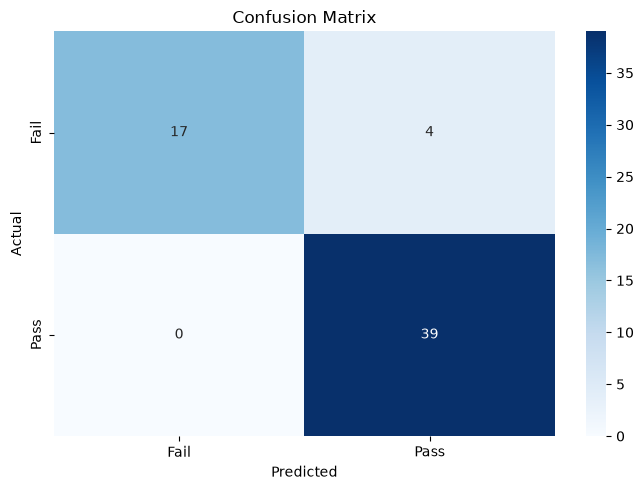


--- New Student Predictions ---
  Study:2h, Attendance:60% → FAIL ❌ (Confidence: 1.1%)
  Study:5h, Attendance:75% → PASS ✅ (Confidence: 81.4%)
  Study:8h, Attendance:90% → PASS ✅ (Confidence: 99.9%)


In [3]:
#  TOPIC 4 — Classification (Logistic Regression)

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
    classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# CLASSIFICATION — Category predict karna
# Pass OR Fail? Spam OR Not Spam?
# ============================================

np.random.seed(42)
n = 300

study_hours = np.random.uniform(1, 10, n)
attendance  = np.random.uniform(50, 100, n)

# Pass = 1, Fail = 0
# MORE study + MORE attendance = pass
passed = ((study_hours * 8 +
           attendance * 0.5 +
           np.random.normal(0, 5, n)) > 70).astype(int)

df = pd.DataFrame({
    'Study_Hours': study_hours,
    'Attendance':  attendance,
    'Passed':      passed
})

print("Dataset:")
print(df.head(10))
print("\nPass/Fail Distribution:")
print(df['Passed'].value_counts())

# Features & Target
X = df[['Study_Hours', 'Attendance']]
y = df['Passed']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Model
model = LogisticRegression(random_state=42)
model.fit(X_train_s, y_train)

# Predict
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]
# predict_proba → probability deta hai 0-1

# ============================================
# EVALUATION METRICS
# ============================================
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fail', 'Pass']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ============================================
# Confusion Matrix Samjho:
# ============================================
# Actual Fail → Predicted Fail = True Negative  ✅
# Actual Pass → Predicted Pass = True Positive  ✅
# Actual Fail → Predicted Pass = False Positive ❌ (wrong alarm)
# Actual Pass → Predicted Fail = False Negative ❌ (missed opportunity)

# ============================================
# NEW STUDENT PREDICTION
# ============================================
new_students = pd.DataFrame({
    'Study_Hours': [2, 5, 8],
    'Attendance':  [60, 75, 90]
})

new_scaled = scaler.transform(new_students)
predictions = model.predict(new_scaled)
probabilities = model.predict_proba(new_scaled)[:, 1]

print("\n--- New Student Predictions ---")
for i, row in new_students.iterrows():
    status = "PASS ✅" if predictions[i] == 1 else "FAIL ❌"
    print(f"  Study:{row['Study_Hours']}h, "
          f"Attendance:{row['Attendance']}% → "
          f"{status} (Confidence: {probabilities[i]*100:.1f}%)")

Decision Tree Accuracy: 88.8%

Feature Importance:
  Study_Hours    : ██████████████████████ 0.7653
  Attendance     : ███ 0.1168
  Prev_Marks     : ███ 0.1179


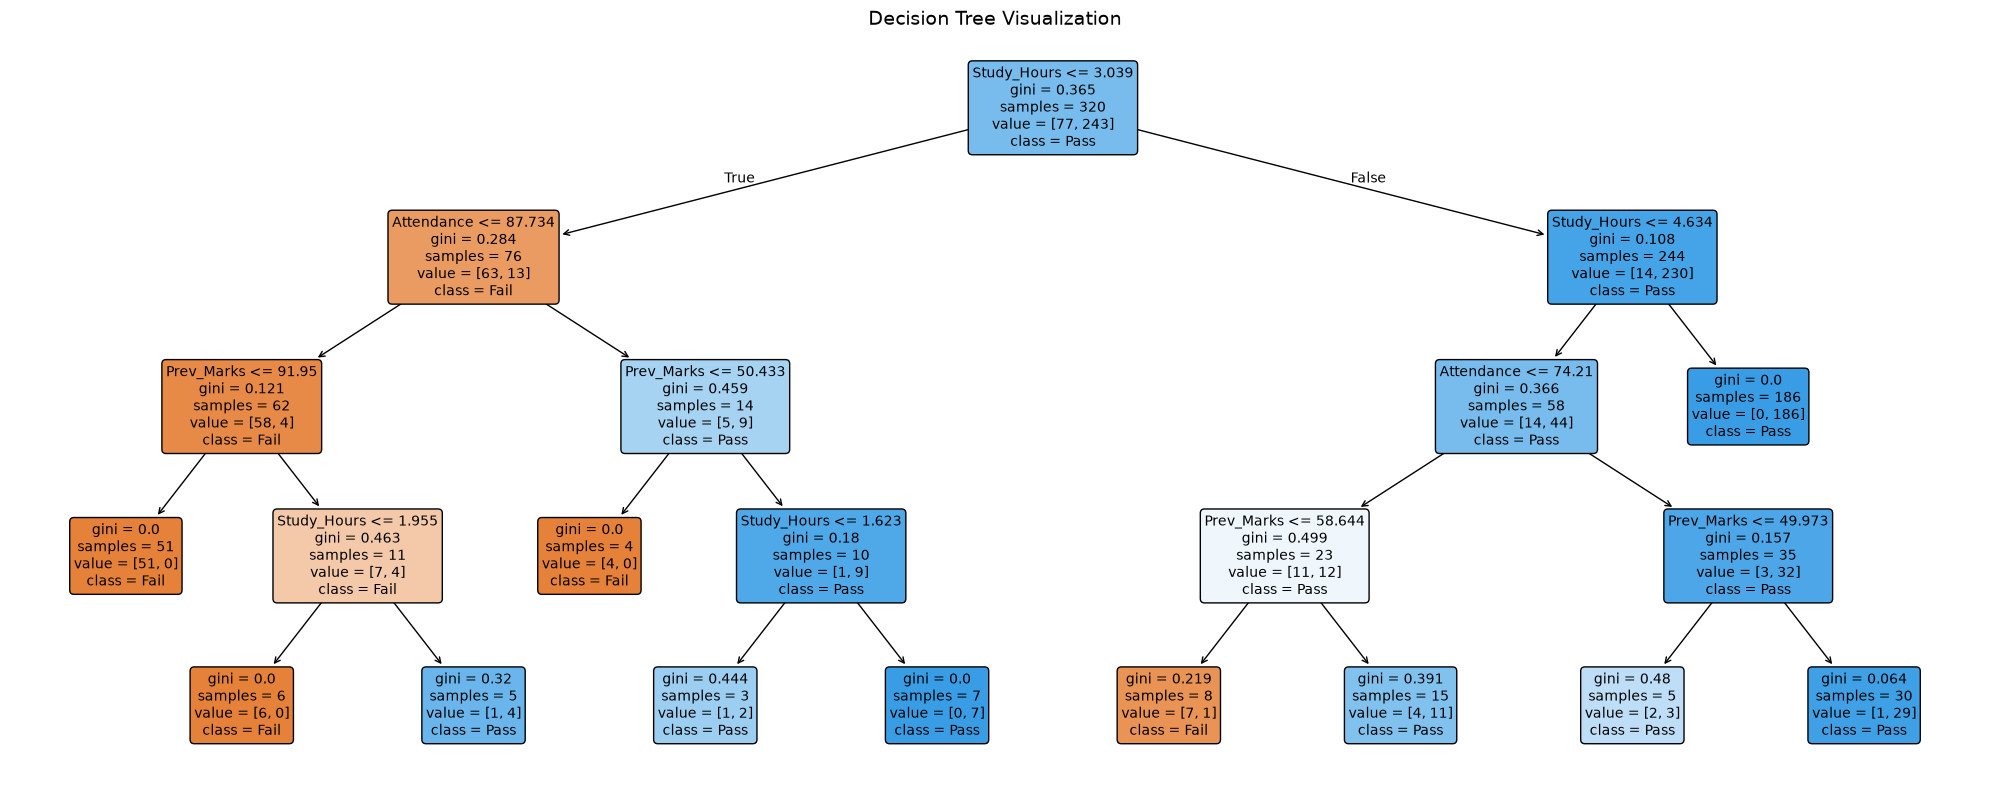

In [4]:
# TOPIC 5 — Decision Tree

import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ============================================
# DECISION TREE — DECIDE AFTER QUESTION!
# ============================================
# EXACTLY LIKE THIS :
# Study > 5 hours?
#   ├── YES → Attendance > 75%?
#   │           ├── YES → PASS ✅
#   │           └── NO  → FAIL ❌
#   └── NO  → FAIL ❌

np.random.seed(42)
n = 400

study     = np.random.uniform(1, 10, n)
attend    = np.random.uniform(50, 100, n)
prev      = np.random.uniform(40, 100, n)

passed = ((study * 7 + attend * 0.4 +
           prev * 0.3 +
           np.random.normal(0, 4, n)) > 72).astype(int)

X = pd.DataFrame({
    'Study_Hours': study,
    'Attendance':  attend,
    'Prev_Marks':  prev
})
y = passed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# Decision Tree Model
# ============================================
dt_model = DecisionTreeClassifier(
    max_depth=4,           # How deep the tree can go
    min_samples_split=10,  # Minimum samples required to split a node
    random_state=42
)
dt_model.fit(X_train, y_train)

y_pred   = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy*100:.1f}%")

# Feature importance
print("\nFeature Importance:")
for feat, imp in zip(X.columns, dt_model.feature_importances_):
    bar = "█" * int(imp * 30)
    print(f"  {feat:15}: {bar} {imp:.4f}")

# Tree visualize karo
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Visualization', fontsize=14)
plt.tight_layout()
plt.show()

Random Forest Accuracy: 98.0%

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.33      0.50         3
        Pass       0.98      1.00      0.99        97

    accuracy                           0.98       100
   macro avg       0.99      0.67      0.74       100
weighted avg       0.98      0.98      0.98       100


Cross Validation Scores: [0.97 0.97 0.97 0.95 0.95]
Mean CV Accuracy: 96.2%
Std: 1.0%


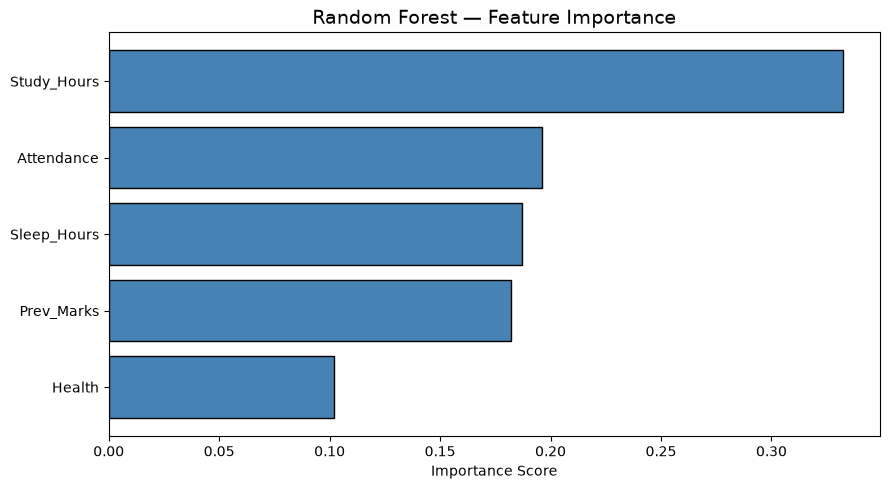

In [5]:
#  TOPIC 6 — Random Forest (Decision Tree's elder Brother!)

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ============================================
# WHAT IS RANDOM FOREST?
# ============================================
# Single Decision Tree → 1 banda decide karta hai
# Random Forest → 100 log milke decide karte hain!
# "Crowd wisdom" — zyada accurate hoti hai!
#
# Make 100 Different Decision Trees
# Eveyr Single Tree will give its own prediction
# whoever gets the most votes — wins!

np.random.seed(42)
n = 500

study    = np.random.uniform(1, 10, n)
sleep    = np.random.uniform(4, 9, n)
attend   = np.random.uniform(50, 100, n)
prev     = np.random.uniform(40, 100, n)
health   = np.random.uniform(1, 10, n)

passed = ((study*6 + sleep*2 + attend*0.3 +
           prev*0.4 + health*1.5 +
           np.random.normal(0, 4, n)) > 72).astype(int)

X = pd.DataFrame({
    'Study_Hours': study,
    'Sleep_Hours': sleep,
    'Attendance':  attend,
    'Prev_Marks':  prev,
    'Health':      health
})
y = passed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# Random Forest
# ============================================
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 trees
    max_depth=5,
    random_state=42,
    n_jobs=-1            # all CPU cores are used
)
rf_model.fit(X_train, y_train)

y_pred   = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Accuracy: {accuracy*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fail','Pass']))

# Cross Validation — Better evaluation!
cv_scores = cross_val_score(rf_model, X, y, cv=5)
print(f"\nCross Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.1f}%")
print(f"Std: {cv_scores.std()*100:.1f}%")

# Feature Importance Plot
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


        MODEL COMPARISON RESULTS
Model                   CV Mean   CV Std   Test Acc
------------------------------------------------------------
Logistic Regression      0.9563   0.0063     0.9625
SVM                      0.9500   0.0063     0.9375
KNN                      0.9406   0.0182     0.9250
Random Forest            0.9313   0.0234     0.9125
Decision Tree            0.9125   0.0322     0.8875

🏆 Best Model: Logistic Regression
   Test Accuracy: 96.2%


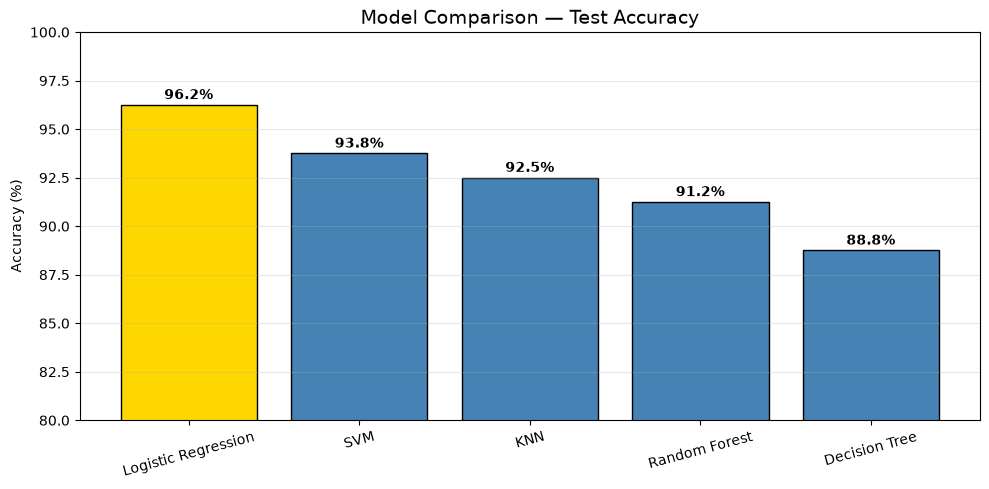

In [6]:
# TOPIC 7 — Model Comparison (Professional Approach!)

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ============================================
# COMPARING MULTIPLE MODELS
# PROFESSIONAL DATA SCIENTISTS DOES THE SAME
# ============================================

np.random.seed(42)
n = 400

study   = np.random.uniform(1, 10, n)
attend  = np.random.uniform(50, 100, n)
prev    = np.random.uniform(40, 100, n)
passed  = ((study*7 + attend*0.4 + prev*0.3 +
            np.random.normal(0,4,n)) > 72).astype(int)

X = pd.DataFrame({
    'Study':      study,
    'Attendance': attend,
    'Prev_Marks': prev
})
y = passed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# DEFINE ALL MODELS
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree':       DecisionTreeClassifier(
                               max_depth=4, random_state=42),
    'Random Forest':       RandomForestClassifier(
                               n_estimators=100, random_state=42),
    'SVM':                 SVC(random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    model.fit(X_train_s, y_train)
    cv    = cross_val_score(model, X_train_s, y_train, cv=5)
    test  = model.score(X_test_s, y_test)
    results.append({
        'Model':    name,
        'CV Mean':  cv.mean(),
        'CV Std':   cv.std(),
        'Test Acc': test
    })

results_df = pd.DataFrame(results).sort_values(
    'Test Acc', ascending=False
)

print("=" * 60)
print("        MODEL COMPARISON RESULTS")
print("=" * 60)
print(f"{'Model':<22} {'CV Mean':>8} {'CV Std':>8} {'Test Acc':>10}")
print("-" * 60)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<22} "
          f"{row['CV Mean']:>8.4f} "
          f"{row['CV Std']:>8.4f} "
          f"{row['Test Acc']:>10.4f}")

# Best model
best = results_df.iloc[0]
print(f"\n🏆 Best Model: {best['Model']}")
print(f"   Test Accuracy: {best['Test Acc']*100:.1f}%")

# Plot
plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue'
          for i in range(len(results_df))]
bars = plt.bar(results_df['Model'],
               results_df['Test Acc'] * 100,
               color=colors, edgecolor='black')

for bar, val in zip(bars, results_df['Test Acc']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val*100:.1f}%',
             ha='center', fontweight='bold')

plt.title('Model Comparison — Test Accuracy', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(80, 100)
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()